In [11]:
import sys
print(sys.executable)
print(sys.version)

/Users/freebird/Downloads/VS Code/prasangapaudel-portfolio/.venv/bin/python
3.13.3 (v3.13.3:6280bb54784, Apr  8 2025, 10:47:54) [Clang 15.0.0 (clang-1500.3.9.4)]


# Public Support for Gasoline Taxes to Finance Renewable Energy
## The Role of Informational Framing and Fuel Prices

### Manuscript Visualization Notebook

This notebook collects the Python visualizations developed for the manuscript in one reproducible, long-form document. Each section presents the purpose of a figure, the Python code used to generate it, and the resulting visualization. The individual scripts are kept in this same folder so they can also be reused independently.

## 1. Regression coefficients: OLS

The first visualization compares standardized OLS coefficients and 95% confidence intervals under the current gasoline-price scenario and the $2.50-per-gallon scenario.

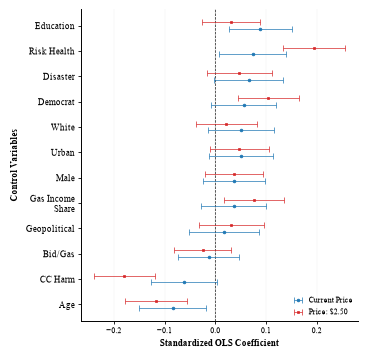


--------------------------------------------
OLS coefficient figure created
--------------------------------------------

PDF:
/Users/freebird/Library/CloudStorage/OneDrive-TexasTechUniversity/VS Code/python/EnergyPolicy_OLS_Coefficients_90mm.pdf

TIFF:
/Users/freebird/Library/CloudStorage/OneDrive-TexasTechUniversity/VS Code/python/EnergyPolicy_OLS_Coefficients_90mm_1200dpi.tiff

--------------------------------------------
Figure width: 3.5433 inches
Figure width: 90.0 mm

Figure height: 3.54 inches
Figure height: 90.0 mm

TIFF resolution: 72 DPI
PDF: Vector format
--------------------------------------------


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# MODEL 1: CURRENT PRICE (OLS)
# ============================================================

data1 = {

    "Variable": [
        "Geopolitical",
        "CC Harm",
        "Disaster",
        "Bid/Gas",
        "Age",
        "Male",
        "White",
        "Education",
        "Democrat",
        "Gas Income\nShare",
        "Risk Health",
        "Urban"
    ],

    "beta": [
        0.01758,
        -0.06142,
        0.06570,
        -0.01250,
        -0.08381,
        0.03746,
        0.05111,
        0.08916,
        0.05642,
        0.03653,
        0.07366,
        0.05079
    ],

    "lower": [
        -0.05142,
        -0.12650,
        -0.00321,
        -0.07266,
        -0.15006,
        -0.02332,
        -0.01337,
        0.02764,
        -0.00756,
        -0.02747,
        0.00766,
        -0.01178
    ],

    "upper": [
        0.08657,
        0.00367,
        0.13461,
        0.04767,
        -0.01756,
        0.09824,
        0.11559,
        0.15068,
        0.12039,
        0.10054,
        0.13967,
        0.11336
    ]
}


df1 = pd.DataFrame(data1)

df1["Model"] = "Current Price"


# ============================================================
# MODEL 2: $2.50 PRICE (OLS)
# ============================================================

data2 = {

    "Variable": [
        "Geopolitical",
        "CC Harm",
        "Disaster",
        "Bid/Gas",
        "Age",
        "Male",
        "White",
        "Education",
        "Democrat",
        "Gas Income\nShare",
        "Risk Health",
        "Urban"
    ],

    "beta": [
        0.03170,
        -0.17898,
        0.04726,
        -0.02488,
        -0.11647,
        0.03702,
        0.02137,
        0.03154,
        0.10500,
        0.07643,
        0.19433,
        0.04724
    ],

    "lower": [
        -0.03262,
        -0.23965,
        -0.01698,
        -0.08096,
        -0.17823,
        -0.01964,
        -0.03874,
        -0.02581,
        0.04537,
        0.01677,
        0.13281,
        -0.01109
    ],

    "upper": [
        0.09602,
        -0.11830,
        0.11150,
        0.03120,
        -0.05472,
        0.09368,
        0.08148,
        0.08889,
        0.16464,
        0.13609,
        0.25586,
        0.10556
    ]
}


df2 = pd.DataFrame(data2)

df2["Model"] = "Price: $2.50"


# ============================================================
# COMBINE DATA
# ============================================================

df = pd.concat(
    [df1, df2],
    ignore_index=True
)


# ============================================================
# ORDER VARIABLES BY MODEL 1 COEFFICIENT
# ============================================================

order = (
    df1
    .sort_values("beta")["Variable"]
    .tolist()
)


df["Variable"] = pd.Categorical(

    df["Variable"],

    categories=order,

    ordered=True
)


df = df.sort_values(
    "Variable"
)


# ============================================================
# ELSEVIER SMALL-COLUMN SETTINGS
# ============================================================

# Elsevier small/single-column width:
#
# 90 mm = 3.5433 inches

FIG_WIDTH = 90 / 25.4


# Keep the same square format as the Probit figure.

FIG_HEIGHT = 90 / 25.4


# TIFF resolution

DPI = 72


# ============================================================
# PUBLICATION STYLE
# ============================================================

plt.rcParams.update({

    # --------------------------------------------------------
    # Font
    # --------------------------------------------------------

    "font.family": "Times New Roman",

    "font.size": 6.5,

    "axes.labelsize": 6.5,

    "xtick.labelsize": 5.5,

    "ytick.labelsize": 6.2,

    "legend.fontsize": 5.8,

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    "axes.linewidth": 0.7,

    # --------------------------------------------------------
    # Ticks
    # --------------------------------------------------------

    "xtick.major.width": 0.6,

    "ytick.major.width": 0.6,

    # --------------------------------------------------------
    # Background
    # --------------------------------------------------------

    "figure.facecolor": "white",

    "axes.facecolor": "white"
})


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(

    figsize=(

        FIG_WIDTH,

        FIG_HEIGHT
    )
)


# ============================================================
# Y POSITIONS
# ============================================================

y_pos = np.arange(
    len(order)
)


# Distance between the two model estimates

offset = 0.13


# ============================================================
# COLORS
# ============================================================

colors = {

    "Current Price": "#1f77b4",

    "Price: $2.50": "#d62728"
}


# ============================================================
# MODEL 1: CURRENT PRICE
# ============================================================

df_m1 = df[
    df["Model"] == "Current Price"
]


ax.errorbar(

    df_m1["beta"],

    y_pos - offset,

    xerr=[

        df_m1["beta"] - df_m1["lower"],

        df_m1["upper"] - df_m1["beta"]
    ],

    # Circle marker

    fmt="o",

    # Small but visible marker

    markersize=2,

    markeredgewidth=0.5,

    markeredgecolor=colors["Current Price"],

    # Thin confidence interval

    linewidth=0.5,

    elinewidth=0.5,

    capsize=2,

    capthick=0.5,

    color=colors["Current Price"],

    label="Current Price",

    zorder=4
)


# ============================================================
# MODEL 2: $2.50 PRICE
# ============================================================

df_m2 = df[
    df["Model"] == "Price: $2.50"
]


ax.errorbar(

    df_m2["beta"],

    y_pos + offset,

    xerr=[

        df_m2["beta"] - df_m2["lower"],

        df_m2["upper"] - df_m2["beta"]
    ],

    # Square marker

    fmt="s",

    markersize=2,

    markeredgewidth=0.5,

    markeredgecolor=colors["Price: $2.50"],

    # Thin confidence interval

    linewidth=0.5,

    elinewidth=0.5,

    capsize=2,

    capthick=0.5,

    color=colors["Price: $2.50"],

    label="Price: $2.50",

    zorder=4
)


# ============================================================
# ZERO REFERENCE LINE
# ============================================================

ax.axvline(

    0,

    color="black",

    linewidth=0.5,

    linestyle="--",

    zorder=1
)


# ============================================================
# Y AXIS
# ============================================================

ax.set_yticks(
    y_pos
)


ax.set_yticklabels(

    order,

    fontsize=6.2
)


# ------------------------------------------------------------
# Y-AXIS TITLE
# ------------------------------------------------------------

ax.set_ylabel(

    "Control Variables",

    fontsize=6.5,

    fontweight="bold",

    labelpad=5
)


# ============================================================
# X AXIS
# ============================================================

ax.set_xlabel(

    "Standardized OLS Coefficient",

    fontsize=6.5,

    fontweight="bold",

    labelpad=3
)


# ============================================================
# X-AXIS TICKS
# ============================================================

ax.tick_params(

    axis="x",

    which="major",

    width=0.6,

    length=2.5,

    pad=2,

    labelsize=5.5
)


# ============================================================
# Y-AXIS TICKS
# ============================================================

ax.tick_params(

    axis="y",

    which="major",

    width=0.6,

    length=2.5,

    pad=2,

    labelsize=6.2
)


# ============================================================
# GRID
# ============================================================

ax.grid(

    axis="x",

    color="0.88",

    linewidth=0.15,

    alpha=0.95,

    zorder=0
)


ax.grid(

    axis="y",

    visible=False
)


# ============================================================
# SPINES
# ============================================================

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.7)

ax.spines["bottom"].set_linewidth(0.7)


# ============================================================
# Y LIMITS
# ============================================================

ax.set_ylim(

    -0.65,

    len(order) - 0.35
)


# ============================================================
# LEGEND
# ============================================================

ax.legend(

    frameon=False,

    loc="lower right",

    fontsize=5.8,

    handlelength=1.8,

    handletextpad=0.4,

    borderaxespad=0.2
)


# ============================================================
# LAYOUT
# ============================================================

# Exact 90-mm canvas.
#
# The left margin gives enough room for the
# control-variable names and y-axis title.

plt.subplots_adjust(

    left=0.20,

    right=0.98,

    bottom=0.10,

    top=0.98
)


# ============================================================
# OUTPUT LOCATION
# ============================================================

output_base = (

    "/Users/freebird/Library/CloudStorage/"
    "OneDrive-TexasTechUniversity/VS Code/python/"
    "EnergyPolicy_OLS_Coefficients_90mm"
)


# ============================================================
# SAVE VECTOR PDF
# ============================================================

pdf_path = (

    output_base +

    ".pdf"
)


fig.savefig(

    pdf_path,

    format="pdf",

    # IMPORTANT:
    # Do not crop.
    #
    # This preserves the exact 90-mm canvas width.

    bbox_inches=None,

    pad_inches=0,

    facecolor="white",

    edgecolor="white"
)


# ============================================================
# SAVE 600-DPI TIFF
# ============================================================
#
#tiff_path = (
#
#    output_base +
#
#    "_1200dpi.tiff"
#)
#
#
#fig.savefig(
#
#    tiff_path,
#
#    format="tiff",
#
#    dpi=DPI,
#
#    # Preserve exact 90-mm canvas.
#
#    bbox_inches=None,
#
#    pad_inches=0,
#
#    facecolor="white",
#
#    edgecolor="white"
#)


# ============================================================
# DISPLAY
# ============================================================

plt.show()


# ============================================================
# PRINT OUTPUT INFORMATION
# ============================================================

print()

print("--------------------------------------------")

print("OLS coefficient figure created")

print("--------------------------------------------")

print()

print("PDF:")

print(pdf_path)

print()

print("TIFF:")

print(tiff_path)

print()

print("--------------------------------------------")

print(
    f"Figure width: "
    f"{FIG_WIDTH:.4f} inches"
)

print(
    "Figure width: 90.0 mm"
)

print()

print(
    f"Figure height: "
    f"{FIG_HEIGHT:.2f} inches"
)

print(
    f"Figure height: "
    f"{FIG_HEIGHT * 25.4:.1f} mm"
)

print()

print(
    f"TIFF resolution: "
    f"{DPI} DPI"
)

print(
    "PDF: Vector format"
)

print("--------------------------------------------")


## 2. Regression coefficients: Probit

The next figure presents standardized Probit coefficients with 95% confidence intervals for the same two price scenarios.

In [13]:
%run "Probit Coeff plot.py"

Exception: File `'Probit Coeff plot.py'` not found.

## 3. Climate-change perceptions

This six-panel figure summarizes the distribution of respondents' perceptions of climate change, the importance and worry associated with global warming, perceived harms, and support for increasing fossil-fuel taxes.

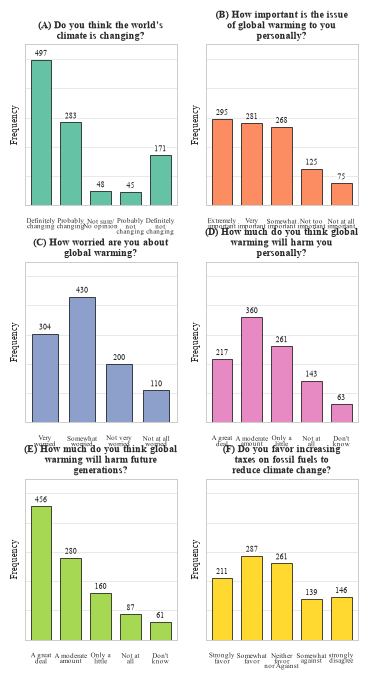

In [ ]:
%run "climate perception.py"

## 4. Risk perceptions

This figure presents the frequency distributions for general, health, family, financial, driving, sports, and job risk perceptions.

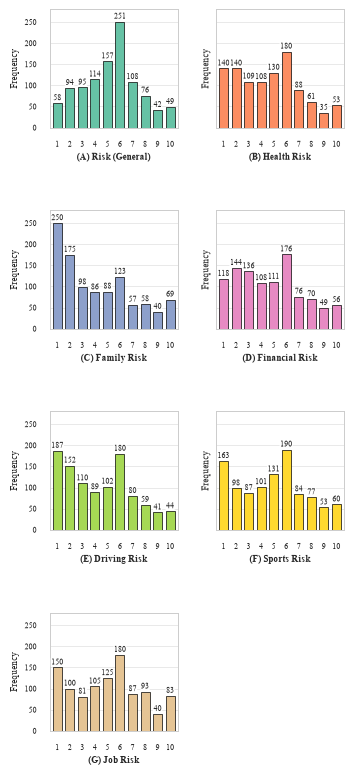

In [ ]:
%run "risk2.py"

## 5. Support under the $2.50 gasoline-price scenario

This six-panel visualization shows predicted/estimated support with confidence intervals across age, gender, education, political affiliation, bid amount, and race groups under the $2.50 scenario.

TypeError: unsupported operand type(s) for -: 'method' and 'float'

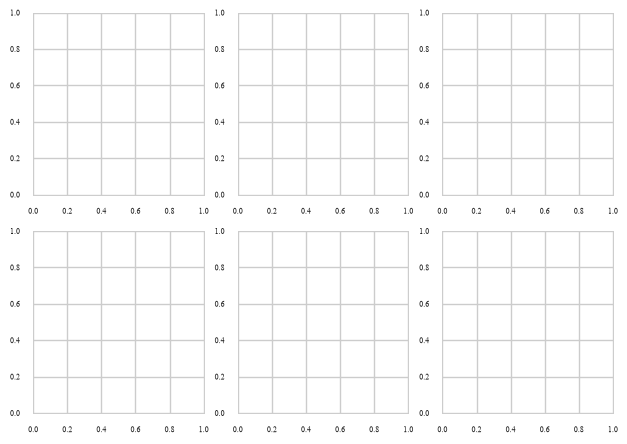

In [ ]:
%run "support across group 250.py"

## 6. Support under the current gasoline-price scenario

The final figure repeats the demographic and bid-group comparison for the current gasoline-price scenario, allowing the two price environments to be compared directly.

TypeError: unsupported operand type(s) for -: 'method' and 'float'

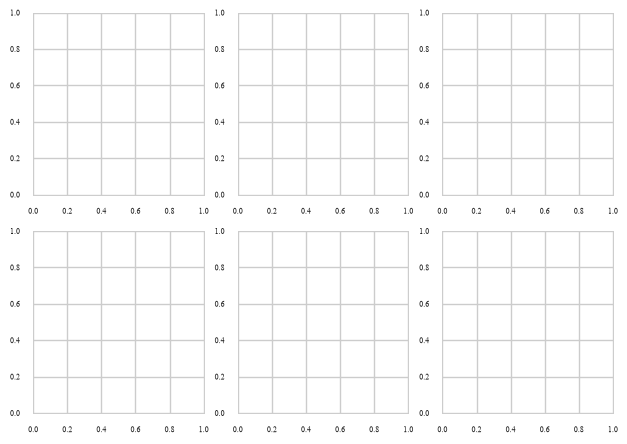

In [ ]:
%run "support across groups current.py"

## Notes for the manuscript

The figures in this notebook are presentation versions of the manuscript visualizations. The underlying scripts preserve the numerical values and publication-oriented figure dimensions used for the article. Before journal submission, figure captions, labels, and numerical inputs should be checked against the final regression and survey-analysis outputs.